In [5]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Load the dataset
df = pd.read_csv(r'C:\Users\asala\OneDrive\Documents\dataviz-exercise--Asala-Nithish\final_project\data\spotify-tracks-dataset-detailed.csv')
# Drop missing values for clean analysis
df = df.dropna()

# Convert duration from ms to minutes for better readability
df['duration_min'] = df['duration_ms'] / 60000

# Define a CVD-safe highlight palette (Okabe-Ito inspired)
CVD_BLUE = "#0072B2"
CVD_ORANGE = "#D55E00"
MUTED_GREY = "#CCCCCC"

def apply_clean_theme(fig):
    """Applies decluttered, publication-ready design principles."""
    fig.update_layout(
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=False, zeroline=False, title_font=dict(size=12, color='gray')),
        yaxis=dict(showgrid=False, zeroline=False, title_font=dict(size=12, color='gray')),
        title=dict(font=dict(size=16, color='black'), pad=dict(b=20)),
        margin=dict(t=60, l=40, r=40, b=40)
    )
    return fig

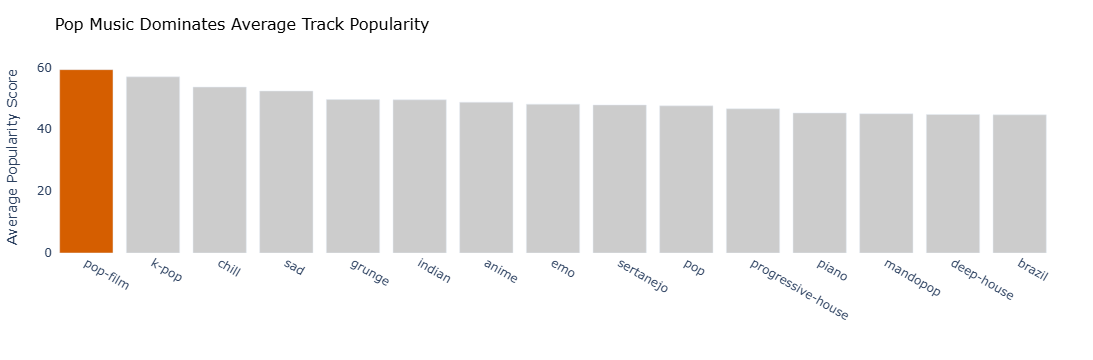

In [6]:
# Insight: Highlighting the single most popular genre against the rest
top_genres = df.groupby('track_genre')['popularity'].mean().nlargest(15).reset_index()

fig = px.bar(top_genres, x='track_genre', y='popularity', 
             title='Pop Music Dominates Average Track Popularity')

# Highlight the top bar, mute the rest
colors = [CVD_ORANGE if i == 0 else MUTED_GREY for i in range(len(top_genres))]
fig.update_traces(marker_color=colors)

fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="", yaxis_title="Average Popularity Score")
fig.show()

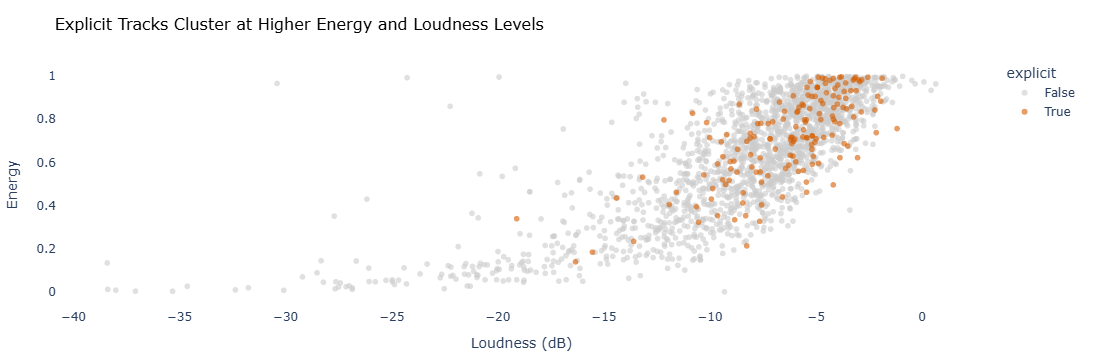

In [7]:
# Insight: Explicit tracks tend to cluster at higher energy and loudness levels
sample_df = df.sample(2000, random_state=42) # Sample to avoid severe overplotting
fig = px.scatter(sample_df, x='loudness', y='energy', color='explicit',
                 color_discrete_map={True: CVD_ORANGE, False: MUTED_GREY},
                 opacity=0.6,
                 title='Explicit Tracks Cluster at Higher Energy and Loudness Levels')

fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="Loudness (dB)", yaxis_title="Energy")
fig.show()

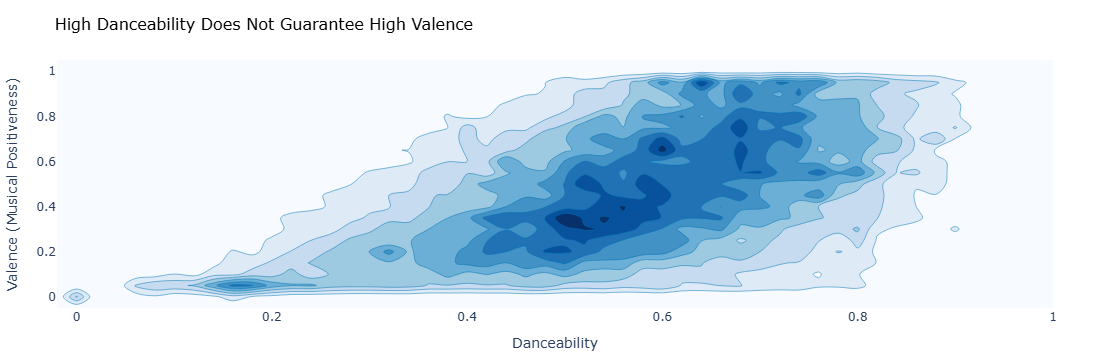

In [8]:
# Insight: Density contour showing where most tracks lie
fig = px.density_contour(df, x='danceability', y='valence',
                         title='High Danceability Does Not Guarantee High Valence',
                         color_discrete_sequence=[CVD_BLUE])

fig.update_traces(contours_coloring="fill", colorscale="Blues", showscale=False)
fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="Danceability", yaxis_title="Valence (Musical Positiveness)")
fig.show()

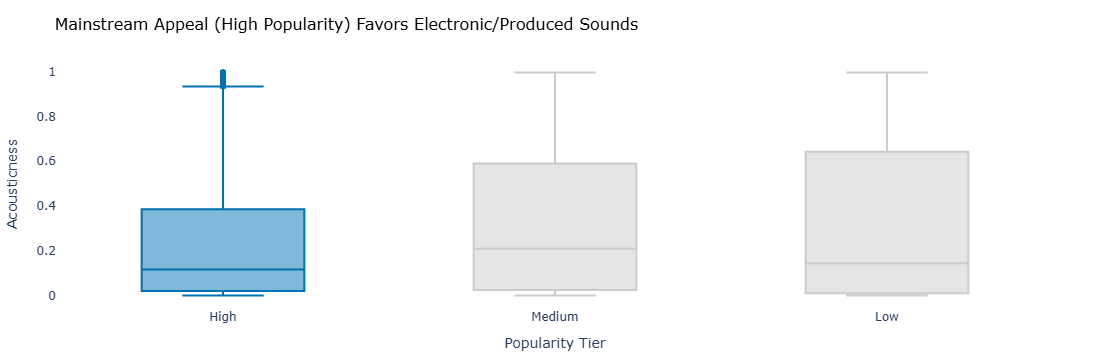

In [9]:
# Insight: Highly popular tracks lean heavily away from acoustic production
df['popularity_tier'] = pd.cut(df['popularity'], bins=[-1, 33, 66, 100], labels=['Low', 'Medium', 'High'])

fig = px.box(df, x='popularity_tier', y='acousticness',
             title='Mainstream Appeal (High Popularity) Favors Electronic/Produced Sounds',
             color='popularity_tier',
             color_discrete_map={'Low': MUTED_GREY, 'Medium': MUTED_GREY, 'High': CVD_BLUE})

fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="Popularity Tier", yaxis_title="Acousticness", showlegend=False)
fig.show()

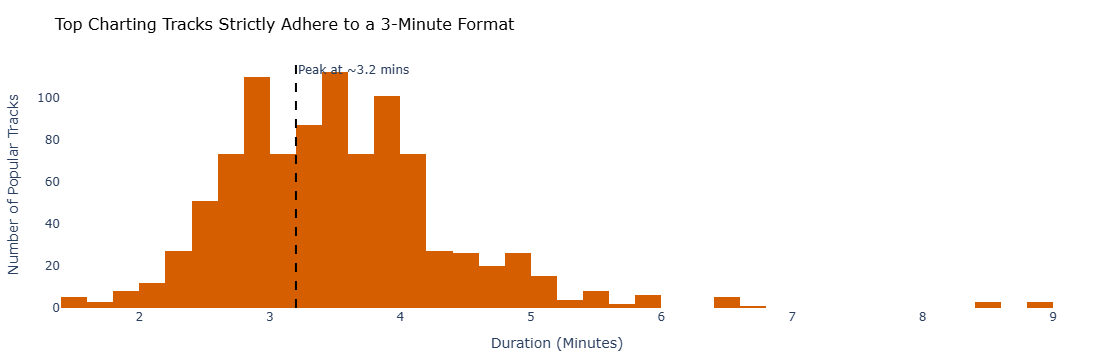

In [10]:
# Insight: Popular songs have a tight distribution around 3 to 3.5 minutes
popular_tracks = df[df['popularity'] > 80]

fig = px.histogram(popular_tracks, x='duration_min', nbins=50,
                   title='Top Charting Tracks Strictly Adhere to a 3-Minute Format',
                   color_discrete_sequence=[CVD_ORANGE])

fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="Duration (Minutes)", yaxis_title="Number of Popular Tracks")
# Add direct annotation
fig.add_vline(x=3.2, line_dash="dash", line_color="black", annotation_text="Peak at ~3.2 mins")
fig.show()

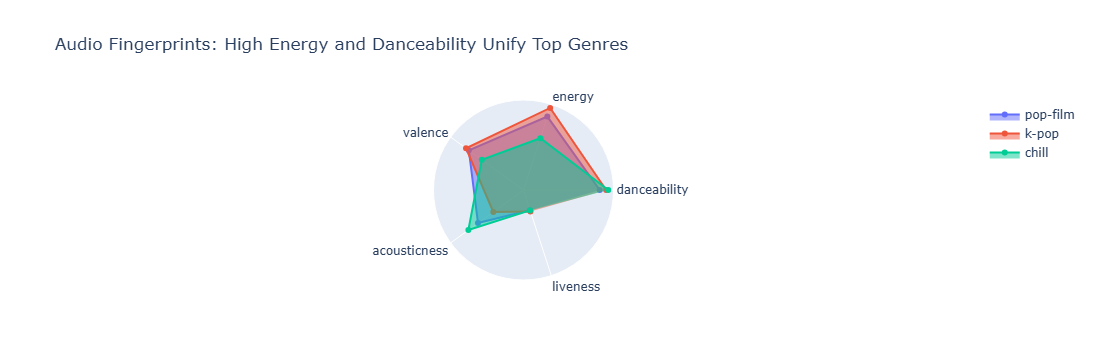

In [11]:
# Insight: Radar chart comparison of mean features
top_3_genres = df.groupby('track_genre')['popularity'].mean().nlargest(3).index
features = ['danceability', 'energy', 'valence', 'acousticness', 'liveness']

radar_data = []
for genre in top_3_genres:
    mean_vals = df[df['track_genre'] == genre][features].mean().values
    radar_data.append(go.Scatterpolar(r=mean_vals, theta=features, fill='toself', name=genre))

fig = go.Figure(data=radar_data)
fig.update_layout(
    title='Audio Fingerprints: High Energy and Danceability Unify Top Genres',
    polar=dict(radialaxis=dict(visible=False)),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.show()

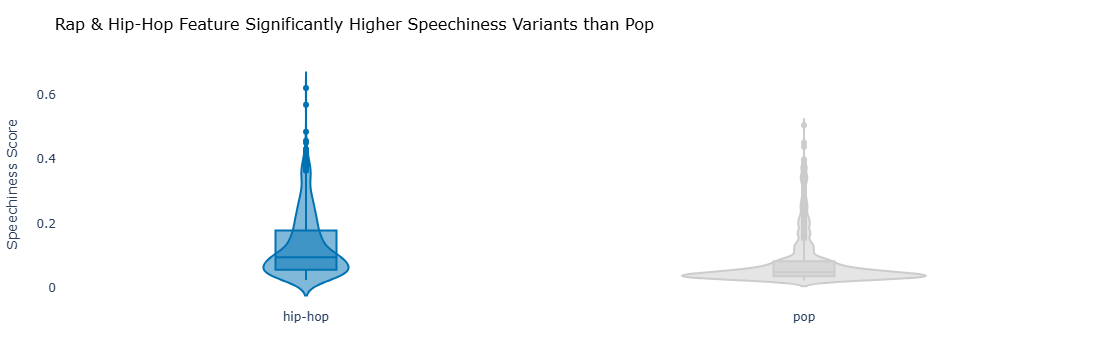

In [12]:
# Insight: Rap tracks have a much wider and higher distribution of spoken words
comparison_df = df[df['track_genre'].isin(['pop', 'hip-hop', 'rap'])]

fig = px.violin(comparison_df, y='speechiness', x='track_genre', box=True,
                title='Rap & Hip-Hop Feature Significantly Higher Speechiness Variants than Pop',
                color='track_genre',
                color_discrete_map={'rap': CVD_ORANGE, 'hip-hop': CVD_BLUE, 'pop': MUTED_GREY})

fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="", yaxis_title="Speechiness Score", showlegend=False)
fig.show()

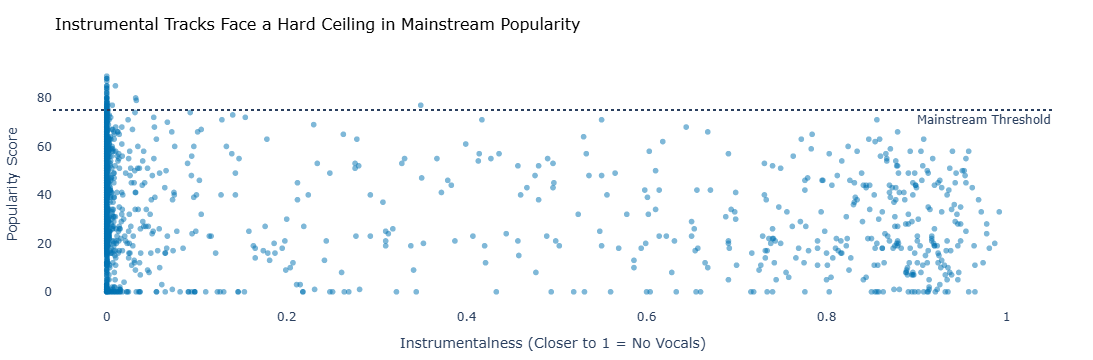

In [13]:
# Insight: High popularity is almost exclusively reserved for tracks with vocals
fig = px.scatter(sample_df, x='instrumentalness', y='popularity', opacity=0.5,
                 title='Instrumental Tracks Face a Hard Ceiling in Mainstream Popularity',
                 color_discrete_sequence=[CVD_BLUE])

fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="Instrumentalness (Closer to 1 = No Vocals)", yaxis_title="Popularity Score")
fig.add_hline(y=75, line_dash="dot", annotation_text="Mainstream Threshold", annotation_position="bottom right")
fig.show()

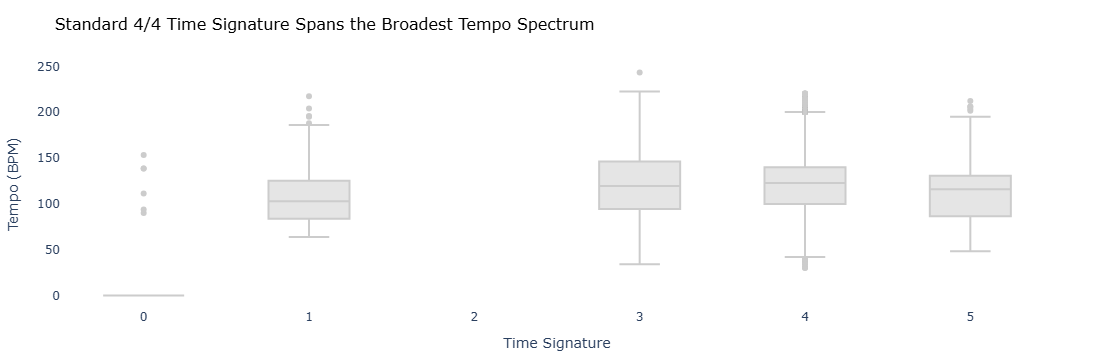

In [14]:
# Insight: 4/4 time signature entirely dominates, holding the widest tempo range
fig = px.box(df, x='time_signature', y='tempo', 
             title='Standard 4/4 Time Signature Spans the Broadest Tempo Spectrum',
             color_discrete_sequence=[MUTED_GREY])

# Highlight time signature 4
fig.update_traces(marker=dict(color=CVD_BLUE), selector=dict(name='4'))

fig = apply_clean_theme(fig)
fig.update_layout(xaxis_title="Time Signature", yaxis_title="Tempo (BPM)")
fig.show()

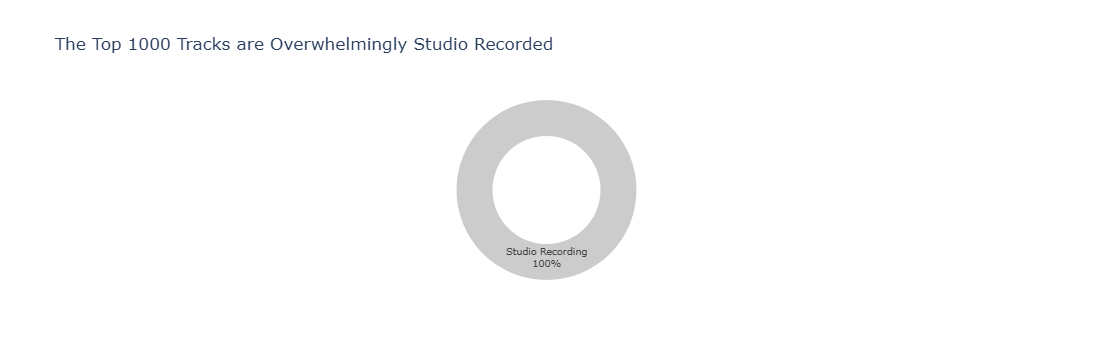

In [15]:
# Insight: Live tracks make up a tiny fraction of top popular music
top_1000 = df.nlargest(1000, 'popularity').copy()
top_1000['is_live'] = np.where(top_1000['liveness'] > 0.8, 'Live Recording', 'Studio Recording')

live_counts = top_1000['is_live'].value_counts().reset_index()
fig = px.pie(live_counts, values='count', names='is_live', 
             title='The Top 1000 Tracks are Overwhelmingly Studio Recorded',
             color='is_live', color_discrete_map={'Studio Recording': MUTED_GREY, 'Live Recording': CVD_ORANGE},
             hole=0.6)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=False)
fig.show()